# Cross-LLM Consistency Study
### EquiAudit Pipeline — Agentic Decision Reproducibility

---

## What was tested

This study measures whether the agentic decisions made by EquiAudit are **consistent across different LLM backends** and **reproducible across repeated runs** of the same model.

Three LLM backends were compared:

| Config | Model | Backend |
|--------|-------|--------|
| `config_qwen` | Qwen2.5-7B | Ollama (local) |
| `config_deepseek` | DeepSeek-R1:8B | Ollama (local) |
| `config_openrouter` | inclusionai/ling-3.0-flash-fin | OpenRouter (cloud) |

Two datasets were used:
- **adult-all.csv** — UCI Adult Census dataset (canonical demographic columns: Age, Race, Sex, etc.)
- **GermanCredit.csv** — Statlog German Credit dataset (domain-specific headers: `personal_status_sex`, `foreign_worker`, etc.)

**10 independent runs** were executed per (model, dataset) combination, giving up to 60 total runs.

### Pipeline stages included

Only the **agentic decision stages** were run — no ML training:

| Stage | Key | What the agent decides |
|-------|-----|------------------------|
| 0 | `0_loading` | Parse the dataset |
| 1 | `1_objective` | Confirm audit objective |
| 2 | `2_quality` | Inspect data quality |
| 3 | `3_sensitive` | **Detect sensitive attributes** (auto mode) |
| 3.5 | `3_5_discretization` | **Discretize continuous attributes** (auto bin choice) |

The agent was also asked to **select the 2 most important intersectional pairs** after Stage 3.

### Three decisions measured

1. **Sensitive attribute detection** — which columns the model flags as sensitive
2. **Pair selection** — which two intersectional attribute pairs the model chooses as highest priority
3. **Discretization bin labels** — the label names the model assigns to numeric bins (e.g., Age bins)

In [1]:
import json
import os
from collections import Counter, defaultdict
from itertools import combinations

import pandas as pd

RESULTS_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'results')

# --- Load all JSON result files ---
runs = []
for fname in sorted(os.listdir(RESULTS_DIR)):
    if fname.endswith('.json') and not fname.startswith('_'):
        with open(os.path.join(RESULTS_DIR, fname)) as f:
            runs.append(json.load(f))

print(f'Loaded {len(runs)} result files')

# Summary
summary = pd.DataFrame([
    {
        'config': r['model_config'].replace('config_', ''),
        'dataset': r['dataset'].replace('.csv', ''),
        'run_id': r['run_id'],
        'n_attrs': r['decisions']['num_sensitive_columns'],
        'n_pairs': len(r['decisions']['pair_selection']['selected_pairs']),
        'pairs': ', '.join(r['decisions']['pair_selection']['selected_pairs']),
        'attrs': ', '.join(r['decisions']['sensitive_columns']),
        'elapsed_s': r['elapsed_seconds'],
    }
    for r in runs
])

summary.head(10)

Loaded 60 result files


,config,dataset,run_id,n_attrs,n_pairs,pairs,attrs,elapsed_s
0,deepseek,GermanCredit,1,2,0,,"age, personal_status_sex",184.8
1,deepseek,GermanCredit,2,3,2,"age + personal_status_sex, age + job","age, personal_status_sex, job",240.6
2,deepseek,GermanCredit,3,2,0,,"age, personal_status_sex",227.9
3,deepseek,GermanCredit,4,0,0,,,170.4
4,deepseek,GermanCredit,5,4,2,"age + personal_status_sex, age + job","age, personal_status_sex, job, foreign_worker",257.8
5,deepseek,GermanCredit,6,3,2,"age + personal_status_sex, age + foreign_worker","age, personal_status_sex, foreign_worker",237.0
6,deepseek,GermanCredit,7,2,0,,"age, job",174.6
7,deepseek,GermanCredit,8,3,2,"age + personal_status_sex, age + foreign_worker","age, personal_status_sex, foreign_worker",261.3
8,deepseek,GermanCredit,9,4,2,"age + personal_status_sex, job + foreign_worker","age, personal_status_sex, job, foreign_worker",220.4
9,deepseek,GermanCredit,10,6,2,"personal_status_sex + foreign_worker, age + job","age, personal_status_sex, employment_duration,...",323.4


## Helper functions

In [2]:
def normalize_pair(p):
    """Sort the two halves of a pair so 'A + B' == 'B + A'."""
    parts = [x.strip() for x in p.split('+')]
    return ' + '.join(sorted(parts))

def normalize_list(lst):
    return frozenset(normalize_pair(s) if '+' in s else s for s in lst)

def mode_of_sets(lists):
    c = Counter(normalize_list(s) for s in lists)
    return c.most_common(1)[0][0] if c else frozenset()

def agreement_rate(lists):
    if not lists:
        return 0.0
    mode = mode_of_sets(lists)
    return sum(1 for lst in lists if normalize_list(lst) == mode) / len(lists)

def jaccard(a, b):
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b) if (a | b) else 1.0

def group_runs(runs):
    groups = defaultdict(list)
    for r in runs:
        groups[(r['model_config'], r['dataset'])].append(r)
    return dict(groups)

## 1. Sensitive Attribute Agreement

For each (model, dataset) combination: what fraction of the 10 runs returned the **exact same set** of sensitive attributes as the most common answer?

In [3]:
groups = group_runs(runs)

attr_rows = []
for (model, dataset), group in sorted(groups.items()):
    lists = [r['decisions']['sensitive_columns'] for r in group]
    rate = agreement_rate(lists)
    mode = sorted(mode_of_sets(lists))
    attr_rows.append({
        'Model': model.replace('config_', ''),
        'Dataset': dataset.replace('.csv', ''),
        'N Runs': len(lists),
        'Agreement %': round(rate * 100, 1),
        'Mode Set (most common)': mode,
    })

attr_df = pd.DataFrame(attr_rows)
attr_df

,Model,Dataset,N Runs,Agreement %,Mode Set (most common)
0,deepseek,GermanCredit,10,20.0,"[age, personal_status_sex]"
1,deepseek,adult-all,10,50.0,"[Age, Education, Marital-status, Native-countr..."
2,openrouter,GermanCredit,10,100.0,"[age, foreign_worker, job, personal_status_sex]"
3,openrouter,adult-all,10,70.0,"[Age, Education, Marital-status, Native-countr..."
4,qwen,GermanCredit,10,20.0,"[age, credit_history, employment_duration, job..."
5,qwen,adult-all,10,60.0,"[Age, Education, Marital-status, Native-countr..."


## 2. Inter-Model Jaccard Similarity

Measures overlap between the **mode attribute sets** of each pair of models on the same dataset.
- Jaccard = 1.0 means perfect agreement
- Jaccard = 0.0 means completely disjoint sets

In [4]:
by_dataset = defaultdict(dict)
for (model, dataset), group in groups.items():
    lists = [r['decisions']['sensitive_columns'] for r in group]
    by_dataset[dataset][model] = mode_of_sets(lists)

jaccard_rows = []
for dataset, model_modes in sorted(by_dataset.items()):
    models = sorted(model_modes.keys())
    for m1, m2 in combinations(models, 2):
        j = jaccard(model_modes[m1], model_modes[m2])
        jaccard_rows.append({
            'Dataset': dataset.replace('.csv', ''),
            'Model A': m1.replace('config_', ''),
            'Model B': m2.replace('config_', ''),
            'Jaccard': round(j, 3),
            'Shared attrs': sorted(model_modes[m1] & model_modes[m2]),
        })

jaccard_df = pd.DataFrame(jaccard_rows)
jaccard_df

,Dataset,Model A,Model B,Jaccard,Shared attrs
0,GermanCredit,deepseek,openrouter,0.500,"[age, personal_status_sex]"
1,GermanCredit,deepseek,qwen,0.222,"[age, personal_status_sex]"
2,GermanCredit,openrouter,qwen,0.300,"[age, job, personal_status_sex]"
3,adult-all,deepseek,openrouter,0.889,"[Age, Education, Marital-status, Native-countr..."
4,adult-all,deepseek,qwen,0.750,"[Age, Education, Marital-status, Native-countr..."
5,adult-all,openrouter,qwen,0.667,"[Age, Education, Marital-status, Native-countr..."


## 3. Pair Selection Consistency

After detecting sensitive attributes, the agent selects the **2 most important intersectional pairs** to audit. How often does each model choose the same pair set across repeated runs?

In [5]:
pair_rows = []
for (model, dataset), group in sorted(groups.items()):
    lists = [r['decisions']['pair_selection']['selected_pairs'] for r in group]
    rate = agreement_rate(lists)
    mode = sorted(mode_of_sets(lists))
    pair_rows.append({
        'Model': model.replace('config_', ''),
        'Dataset': dataset.replace('.csv', ''),
        'N Runs': len(lists),
        'Agreement %': round(rate * 100, 1),
        'Mode Pairs': mode,
    })

pair_df = pd.DataFrame(pair_rows)
pair_df

,Model,Dataset,N Runs,Agreement %,Mode Pairs
0,deepseek,GermanCredit,10,40.0,[]
1,deepseek,adult-all,10,40.0,"[Age + Education, Race + Sex]"
2,openrouter,GermanCredit,10,70.0,"[age + personal_status_sex, job + personal_sta..."
3,openrouter,adult-all,10,90.0,"[Age + Sex, Race + Sex]"
4,qwen,GermanCredit,10,20.0,"[age + employment_duration, personal_status_se..."
5,qwen,adult-all,10,50.0,"[Age + Marital-status, Race + Sex]"


## 4. Discretization Label Consistency

For each continuous attribute that was discretized (e.g., Age), how often did the model use the **exact same bin labels** across runs?

In [6]:
disc_rows = []
for (model, dataset), group in sorted(groups.items()):
    disc_by_attr = defaultdict(list)
    for r in group:
        for attr, info in r['decisions']['discretization'].items():
            disc_by_attr[attr].append(tuple(info.get('labels', [])))

    for attr, label_runs in sorted(disc_by_attr.items()):
        c = Counter(label_runs)
        exact = c.most_common(1)[0][1] / len(label_runs)
        disc_rows.append({
            'Model': model.replace('config_', ''),
            'Dataset': dataset.replace('.csv', ''),
            'Attribute': attr,
            'N Runs': len(label_runs),
            'Exact Match %': round(exact * 100, 1),
            'Most Common Labels': list(c.most_common(1)[0][0]),
        })

disc_df = pd.DataFrame(disc_rows)
disc_df

,Model,Dataset,Attribute,N Runs,Exact Match %,Most Common Labels
0,deepseek,GermanCredit,age,9,55.6,"[Young, Middle-Aged, Senior, Elderly]"
1,deepseek,adult-all,Age,10,50.0,"[Young, Middle-Aged, Senior, Elderly]"
2,deepseek,adult-all,Hours-per-week,1,100.0,"[Part-time, Full-time (moderate), Full-time (h..."
3,openrouter,GermanCredit,age,10,70.0,"[Young, Middle-Aged, Senior, Elderly]"
4,openrouter,adult-all,Age,10,40.0,"[Young, Middle-Aged, Senior, Elderly]"
5,qwen,GermanCredit,age,10,30.0,"[Young, Middle-Aged, Senior]"
6,qwen,adult-all,Age,10,40.0,"[Teen, Young Adult, Middle-Aged, Mature, Senior]"


## 5. Run-level Overview

In [7]:
pivot = summary.groupby(['config', 'dataset']).agg(
    runs=('run_id', 'count'),
    avg_attrs=('n_attrs', 'mean'),
    avg_pairs=('n_pairs', 'mean'),
    avg_elapsed=('elapsed_s', 'mean'),
).round(1)
pivot

runs  avg_attrs  avg_pairs  avg_elapsed
config     dataset                                              
deepseek   GermanCredit    10        2.9        1.2        229.8
           adult-all       10        7.6        2.0        272.4
openrouter GermanCredit    10        4.0        2.0         42.5
           adult-all       10        8.1        1.8         32.0
qwen       GermanCredit    10        8.5        2.0         90.8
           adult-all       10        6.2        2.0         84.0

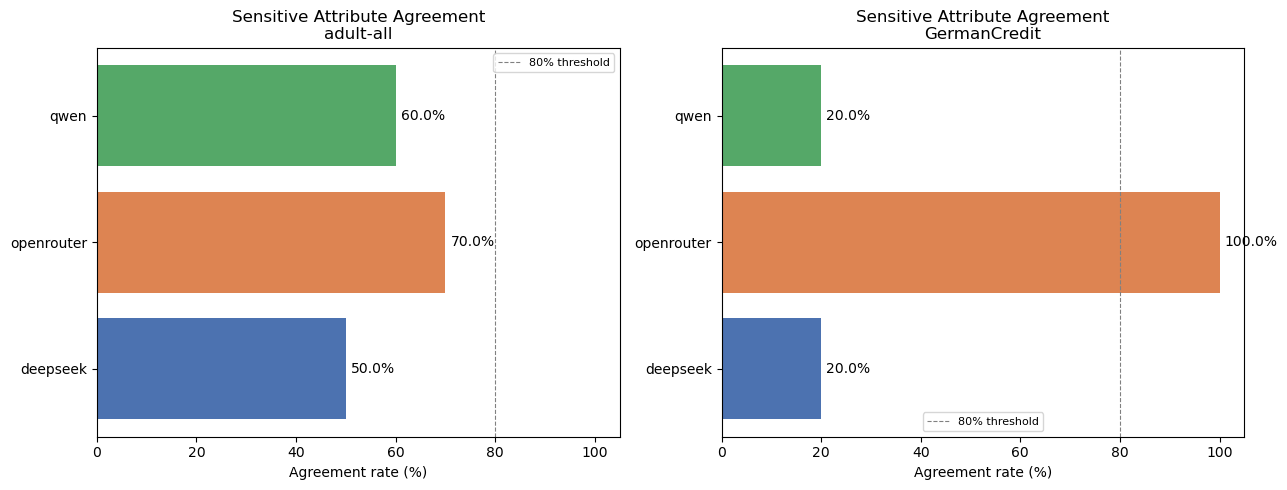

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, dataset in zip(axes, ['adult-all', 'GermanCredit']):
    sub = attr_df[attr_df['Dataset'] == dataset]
    colors = ['#4C72B0', '#DD8452', '#55A868']
    bars = ax.barh(sub['Model'], sub['Agreement %'], color=colors[:len(sub)])
    ax.set_xlim(0, 105)
    ax.set_xlabel('Agreement rate (%)')
    ax.set_title(f'Sensitive Attribute Agreement\n{dataset}')
    ax.axvline(80, color='gray', linestyle='--', linewidth=0.8, label='80% threshold')
    for bar, val in zip(bars, sub['Agreement %']):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('attr_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

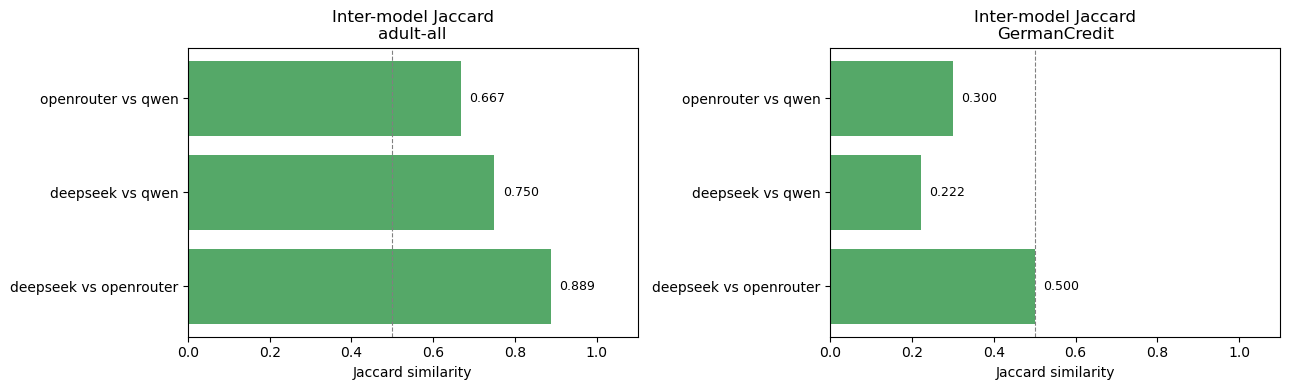

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, dataset in zip(axes, ['adult-all', 'GermanCredit']):
    sub = jaccard_df[jaccard_df['Dataset'] == dataset].copy()
    sub['pair_label'] = sub['Model A'] + ' vs ' + sub['Model B']
    ax.barh(sub['pair_label'], sub['Jaccard'], color='#55A868')
    ax.set_xlim(0, 1.1)
    ax.set_xlabel('Jaccard similarity')
    ax.set_title(f'Inter-model Jaccard\n{dataset}')
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
    for i, (val, row) in enumerate(zip(sub['Jaccard'], sub.itertuples())):
        ax.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('jaccard_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusions

The detailed writeup goes to Appendix D of the paper. Key findings at a glance:

### Intra-model reproducibility (same model, repeated runs)
- **Ling-3.0-Flash-Fin** is the most stable model overall: 70% attribute agreement on adult-all and 100% on GermanCredit, the only perfect within-model score in the study.
- **Qwen2.5-7B** reaches 60% on adult-all but drops to 20% on GermanCredit.
- **DeepSeek-R1:8B** reaches 50% on adult-all and 20% on GermanCredit. On GermanCredit it tends to fall back to generic demographic labels (`sex`, `native-country`) instead of the actual column names (`personal_status_sex`, `foreign_worker`). The pipeline validator discards those non-existent columns, leaving 0-2 valid attributes in the affected runs.

### Inter-model agreement (across different LLMs)
- On **adult-all** (canonical headers): Jaccard ranges from 0.667 to 0.889, so all three models converge on broadly the same core set of demographic attributes (Age, Race, Sex, Education, etc.).
- On **GermanCredit** (domain-specific headers): Jaccard is much lower (0.222-0.500). The lowest value is DeepSeek vs Qwen (0.222), driven mainly by DeepSeek's substitution of generic names. Ling, the most stable model here, also shows the highest overlap with both others.

### Pair selection
- **Race + Sex** is selected as a top pair in 29 of the 30 adult-all runs. The one exception is a run that detected only two sensitive attributes, so no pair selection was performed at all.
- Pair agreement is highest for Ling (90% on adult-all, 70% on GermanCredit) and lowest for Qwen on GermanCredit (20%).
- GermanCredit pairs vary more across models, consistent with the attribute detection divergence.

### Discretization
- Age bin labels are only moderately stable within a model: exact-match rates range from 30% (Qwen on GermanCredit) to 70% (Ling on GermanCredit).
- Variation comes from both label naming and the choice of binning strategy, so this decision is not treated as a headline result in the paper.

### Implication for the paper
EquiAudit's **numerical tool outputs are deterministic** (no LLM involved in metric computation), and this was verified to hold across all 60 runs. The agentic decisions (which attributes, which pairs) are consistent for datasets with canonical headers and noticeably more variable for domain-specific ones. This motivates both the use of capable models and the mandatory human confirmation gate at Stage 3, where the analyst approves or overrides the auto-detected attribute list.
